In [2]:
import os
import json
from Agent.utils import *
from Agent.data_agent import SalesDataAgent

agent = SalesDataAgent(
    provider="openai",
    model="gpt-4o-mini",
    temperature=0.1,
    max_tokens=16384,
    #enable_tracing=True,
    #phoenix_endpoint="http://localhost:6006/v1/traces",
    streaming=True,
)

CodeCarbon is available
<module 'langgraph.version' from '/home/oss/Desktop/DataAgent/venv/lib64/python3.12/site-packages/langgraph/version.py'>


In [3]:
result = agent.run(
    "Show me the sales in Nov 2021",
    visualization_goal="Sales trend for Nov 2021, with date as x and sales value as y",
    #best_of_n = 3
)

[Agent] Running best-of-1 with temperatures: [0.1]
Checking the model can run locally
OpenAI API is accessible
Running the graph...
[LangGraph] Starting LangGraph execution
Tool selected: lookup_sales_data
Generated SQL Query:
 SELECT Sold_Date, SUM(Total_Sale_Value) as Total_Sales_Value 
FROM sales 
WHERE CAST(Sold_Date AS VARCHAR) LIKE '%2021-11%' 
GROUP BY Sold_Date 
ORDER BY Sold_Date;
Tool selected: analyzing_data
Tool selected: create_visualization
Using DataFrame with shape: (29, 2), columns: ['Sold_Date', 'Total_Sales_Value']
This is the chart_config: {'chart_type': 'line', 'x_axis': 'Sold_Date', 'y_axis': 'Total_Sales_Value', 'title': 'Sales Trend for November 2021'}
Tool selected: end
[LangGraph] LangGraph execution completed
[0.0]


In [4]:
print(type(result))
print(result)
# DV: the output shows that result is a tuple, because it is the return of data_agent.run_with_evaluation, that actually is (best_result, score_variance)

<class 'tuple'>
({'prompt': 'Show me the sales in Nov 2021', 'data': ' Sold_Date  Total_Sales_Value\n2021-11-01       12189.589920\n2021-11-02       12946.209929\n2021-11-03       11030.389963\n2021-11-04       15082.069949\n2021-11-05       22844.579923\n2021-11-06       17849.039923\n2021-11-07       13095.019963\n2021-11-08       12484.549912\n2021-11-09       11814.849948\n2021-11-10       13338.799962\n2021-11-11       18651.919908\n2021-11-12       20851.529951\n2021-11-13       18360.199938\n2021-11-14       13220.839950\n2021-11-15       12458.489944\n2021-11-16       12231.529933\n2021-11-17       13483.629963\n2021-11-18       15048.099882\n2021-11-19       21971.929924\n2021-11-20       18252.069955\n2021-11-21       13697.579933\n2021-11-22       12316.969940\n2021-11-23       16716.979915\n2021-11-25       52004.599937\n2021-11-26       28608.549954\n2021-11-27       21168.689922\n2021-11-28       15602.529922\n2021-11-29       14708.539966\n2021-11-30       17954.649963',

In [5]:
# DV: we are interested in best_result, that is the first element of the tuple
print("Final tool:", result[0].get("tool_choice"))
print("Chart config:", result[0].get("chart_config"))
print("Answer steps:", len(result[0].get("answer", [])))

Final tool: end
Chart config: {'chart_type': 'line', 'x_axis': 'Sold_Date', 'y_axis': 'Total_Sales_Value', 'title': 'Sales Trend for November 2021'}
Answer steps: 2


In [6]:
print("=== LAST ANSWER ===")
print(result[0]["answer"][-1])
print("===================")

=== LAST ANSWER ===
x_data = data_df[config['x_axis']]
y_data = data_df[config['y_axis']]

plt.plot(x_data, y_data, marker='o')
plt.xlabel(config['x_axis'])
plt.ylabel(config['y_axis'])
plt.title(config['title'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


=== CHART CODE ===
x_data = data_df[config['x_axis']]
y_data = data_df[config['y_axis']]

plt.plot(x_data, y_data, marker='o')
plt.xlabel(config['x_axis'])
plt.ylabel(config['y_axis'])
plt.title(config['title'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Executing chart with DataFrame shape: (29, 2)


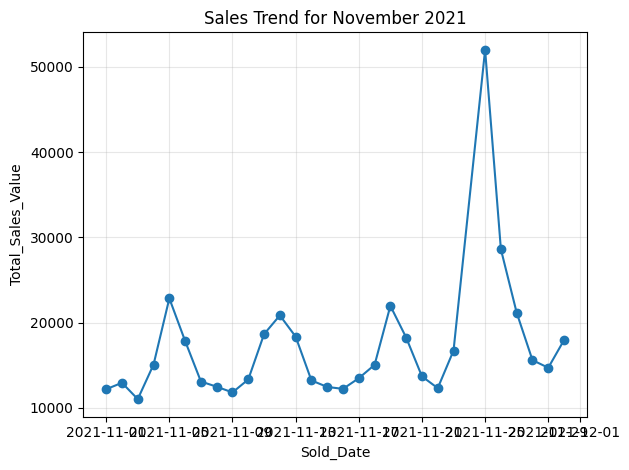

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Get the DataFrame directly from the result (no parsing needed!)
data_df = result[0].get("data_df")
chart_code = result[0]["answer"][-1]

print("=== CHART CODE ===")
print(chart_code)
print("==================\n")

# Execute the chart code with data_df in the namespace
if data_df is not None and chart_code:
    print(f"Executing chart with DataFrame shape: {data_df.shape}")
    
    namespace = {
        "data_df": data_df,
        "pd": pd,
        "plt": plt,
        "config": result[0].get("chart_config", {}),
        "__builtins__": __builtins__
    }
    
    exec(chart_code, namespace)
else:
    print("Warning: No DataFrame or chart code available")


## Visualization Evaluation with LLM-as-a-Judge

The following cells demonstrate how to evaluate visualization quality using LLM-as-a-judge.
This compares generated chart configurations and code against ground truth using semantic similarity.

In [13]:
# Load visualization ground truth
import json

with open("evaluation/visualization_dataset.json", "r") as f:
    vis_gt = json.load(f)

print(f"Loaded {len(vis_gt)} visualization test cases")
print("\nFirst test case:")
print(f"  Prompt: {vis_gt[0]['prompt']}")
print(f"  Visualization Goal: {vis_gt[0]['visualization_goal']}")
print(f"  GT Chart Config: {vis_gt[0]['gt_chart_config']}")

Loaded 4 visualization test cases

First test case:
  Prompt: Show me the sales in Nov 2021
  Visualization Goal: Sales trend for Nov 2021, with date as x and sales value as y
  GT Chart Config: {'chart_type': 'line', 'x_axis': 'Sale_Date', 'y_axis': 'Total_Sales_Value', 'title': 'Sales Trend for November 2021'}


In [14]:
# Create visualization evaluation function using the first test case
from Agent.utils import judge_visualization

# Use the first ground truth entry
gt_entry = vis_gt[0]

def vis_eval_fn(chart_config, chart_code):
    """Evaluate visualization against ground truth using LLM-as-a-judge."""
    score, details = judge_visualization(
        visualization_goal=gt_entry["visualization_goal"],
        generated_config=chart_config,
        generated_code=chart_code,
        gt_config=gt_entry["gt_chart_config"],
        gt_code=gt_entry["gt_chart_code"],
        explicit_requirements=gt_entry.get("explicit_requirements"),
        judge_model="gpt-4o-mini",  # Using gpt-4o-mini for demo, use gpt-5.1 for production
        provider="openai"
    )
    print(f"\n=== Visualization Evaluation ===")
    print(f"Overall Score: {score:.3f}")
    print(f"Details: {json.dumps(details, indent=2)}")
    return score

print("Visualization evaluation function created!")

Visualization evaluation function created!


In [10]:
# Run agent with visualization evaluation and best-of-n
result_with_eval = agent.run(
    gt_entry["prompt"],
    visualization_goal=gt_entry["visualization_goal"],
    vis_eval_fn=vis_eval_fn,
    best_of_n=3,  # Run 3 times and pick the best visualization
    temp=0.1,
    temp_max=0.5
)

print("\n" + "="*60)
print("BEST-OF-N RESULTS")
print("="*60)
print(f"Best visualization score: {result_with_eval[0].get('vis_score', 'N/A')}")
print(f"Score variance: {result_with_eval[1]:.4f}")
print(f"Chart config: {result_with_eval[0].get('chart_config')}")

[Agent] Running best-of-3 with temperatures: [0.1, 0.30000000000000004, 0.5]
Running the graph...
[LangGraph] Starting LangGraph execution
Tool selected: lookup_sales_data
Generated SQL Query:
 SELECT Sold_Date, SUM(Total_Sale_Value) as Total_Sales_Value 
FROM sales 
WHERE CAST(Sold_Date AS VARCHAR) LIKE '%2021-11%' 
GROUP BY Sold_Date 
ORDER BY Sold_Date;
Tool selected: analyzing_data
Tool selected: create_visualization
Using DataFrame with shape: (29, 2), columns: ['Sold_Date', 'Total_Sales_Value']
This is the chart_config: {'chart_type': 'line', 'x_axis': 'Sold_Date', 'y_axis': 'Total_Sales_Value', 'title': 'Sales Trend for November 2021'}
Tool selected: end
[LangGraph] LangGraph execution completed

=== Visualization Evaluation ===
Overall Score: 0.800
Details: {
  "axis_correctness": {
    "score": 3,
    "reasoning": "The x-axis uses 'Sold_Date' instead of 'Sale_Date', which is a partial match. The y-axis 'Total_Sales_Value' matches exactly.",
    "x_match": false,
    "y_match":

=== BEST VISUALIZATION ===
Visualization Score: 0.9999999999999999
Chart Config: {'chart_type': 'line', 'x_axis': 'Sale_Date', 'y_axis': 'Total_Sales_Value', 'title': 'Sales Trend for November 2021'}

=== CHART CODE ===
x_data = data_df[config['x_axis']]
y_data = data_df[config['y_axis']]

plt.plot(x_data, y_data, marker='o')
plt.xlabel(config['x_axis'])
plt.ylabel(config['y_axis'])
plt.title(config['title'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



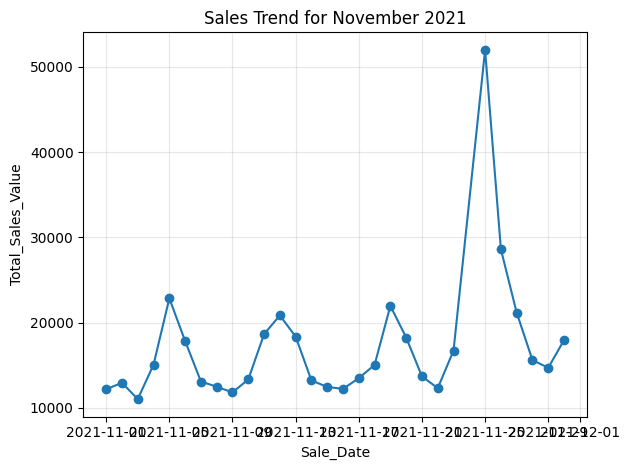

In [7]:
# Display the best visualization from best-of-n evaluation
import matplotlib.pyplot as plt
import pandas as pd

data_df = result_with_eval[0].get("data_df")
chart_code = result_with_eval[0]["answer"][-1]
config = result_with_eval[0].get("chart_config", {})

print("=== BEST VISUALIZATION ===")
print(f"Visualization Score: {result_with_eval[0].get('vis_score', 'N/A')}")
print(f"Chart Config: {config}")
print("\n=== CHART CODE ===")
print(chart_code)
print("==================\n")

# Execute the best chart code
if data_df is not None and chart_code:
    namespace = {
        "data_df": data_df,
        "pd": pd,
        "plt": plt,
        "config": config,
        "__builtins__": __builtins__
    }
    exec(chart_code, namespace)
else:
    print("Warning: No DataFrame or chart code available")

In [15]:
# Evaluate on the entire visualization ground truth dataset with temperature selection
import pandas as pd
from Agent.utils import judge_visualization

results = []

for idx, gt_entry in enumerate(vis_gt):
    print(f"\n{'='*60}")
    print(f"EVALUATING TEST CASE {idx + 1}/{len(vis_gt)}")
    print(f"{'='*60}")
    print(f"Prompt: {gt_entry['prompt']}")
    print(f"Visualization Goal: {gt_entry['visualization_goal']}")
    
    # Create evaluation function for this specific test case
    def vis_eval_fn(chart_config, chart_code):
        """Evaluate visualization against ground truth using LLM-as-a-judge."""
        score, details = judge_visualization(
            visualization_goal=gt_entry["visualization_goal"],
            generated_config=chart_config,
            generated_code=chart_code,
            gt_config=gt_entry["gt_chart_config"],
            gt_code=gt_entry["gt_chart_code"],
            explicit_requirements=gt_entry.get("explicit_requirements"),
            judge_model="gpt-4o-mini",
            provider="openai"
        )
        print(f"\n=== Visualization Evaluation ===")
        print(f"Overall Score: {score:.3f}")
        return score
    
    # Run agent with best-of-n to choose best temperature
    result = agent.run(
        gt_entry["prompt"],
        visualization_goal=gt_entry["visualization_goal"],
        vis_eval_fn=vis_eval_fn,
        best_of_n=3,  # Try 3 different temperatures
        temp=0.1,      # Minimum temperature
        temp_max=0.5   # Maximum temperature
    )
    
    # Store results
    results.append({
        "test_case_id": idx,
        "prompt": gt_entry["prompt"],
        "visualization_goal": gt_entry["visualization_goal"],
        "generated_config": result[0].get("chart_config"),
        "gt_config": gt_entry["gt_chart_config"],
        "vis_score": result[0].get("vis_score"),
        "score_variance": result[1],
        "best_temperature": result[0].get("temperature", "N/A")
    })
    
    print(f"\nTest Case {idx + 1} - Best Score: {result[0].get('vis_score', 'N/A'):.3f} | Variance: {result[1]:.3f}")

# Summary statistics
print(f"\n{'='*60}")
print("OVERALL EVALUATION SUMMARY")
print(f"{'='*60}")

results_df = pd.DataFrame(results)
print(f"\nAverage Visualization Score: {results_df['vis_score'].mean():.3f}")
print(f"Min Score: {results_df['vis_score'].min():.3f}")
print(f"Max Score: {results_df['vis_score'].max():.3f}")
print(f"Std Dev: {results_df['vis_score'].std():.3f}")
print(f"Avg Score Variance: {results_df['score_variance'].mean():.3f}")

print("\n=== Per Test Case Results ===")
print(results_df[['test_case_id', 'prompt', 'vis_score', 'score_variance', 'best_temperature']].to_string(index=False))

# Save detailed results
results_df.to_csv("evaluation/visualization_evaluation_results.csv", index=False)
print("\n✓ Results saved to evaluation/visualization_evaluation_results.csv")


EVALUATING TEST CASE 1/4
Prompt: Show me the sales in Nov 2021
Visualization Goal: Sales trend for Nov 2021, with date as x and sales value as y
[Agent] Running best-of-3 with temperatures: [0.1, 0.30000000000000004, 0.5]
Running the graph...
[LangGraph] Starting LangGraph execution
Tool selected: lookup_sales_data
Generated SQL Query:
 SELECT Sold_Date, SUM(Total_Sale_Value) as Total_Sales_Value 
FROM sales 
WHERE CAST(Sold_Date AS VARCHAR) LIKE '%2021-11%' 
GROUP BY Sold_Date 
ORDER BY Sold_Date;
Tool selected: analyzing_data
Tool selected: create_visualization
Using DataFrame with shape: (29, 2), columns: ['Sold_Date', 'Total_Sales_Value']
This is the chart_config: {'chart_type': 'line', 'x_axis': 'Sold_Date', 'y_axis': 'Total_Sales_Value', 'title': 'Sales Trend for November 2021'}
Tool selected: end
[LangGraph] LangGraph execution completed

=== Visualization Evaluation ===
Overall Score: 0.800
Running the graph...
[LangGraph] Starting LangGraph execution
Tool selected: lookup_sal

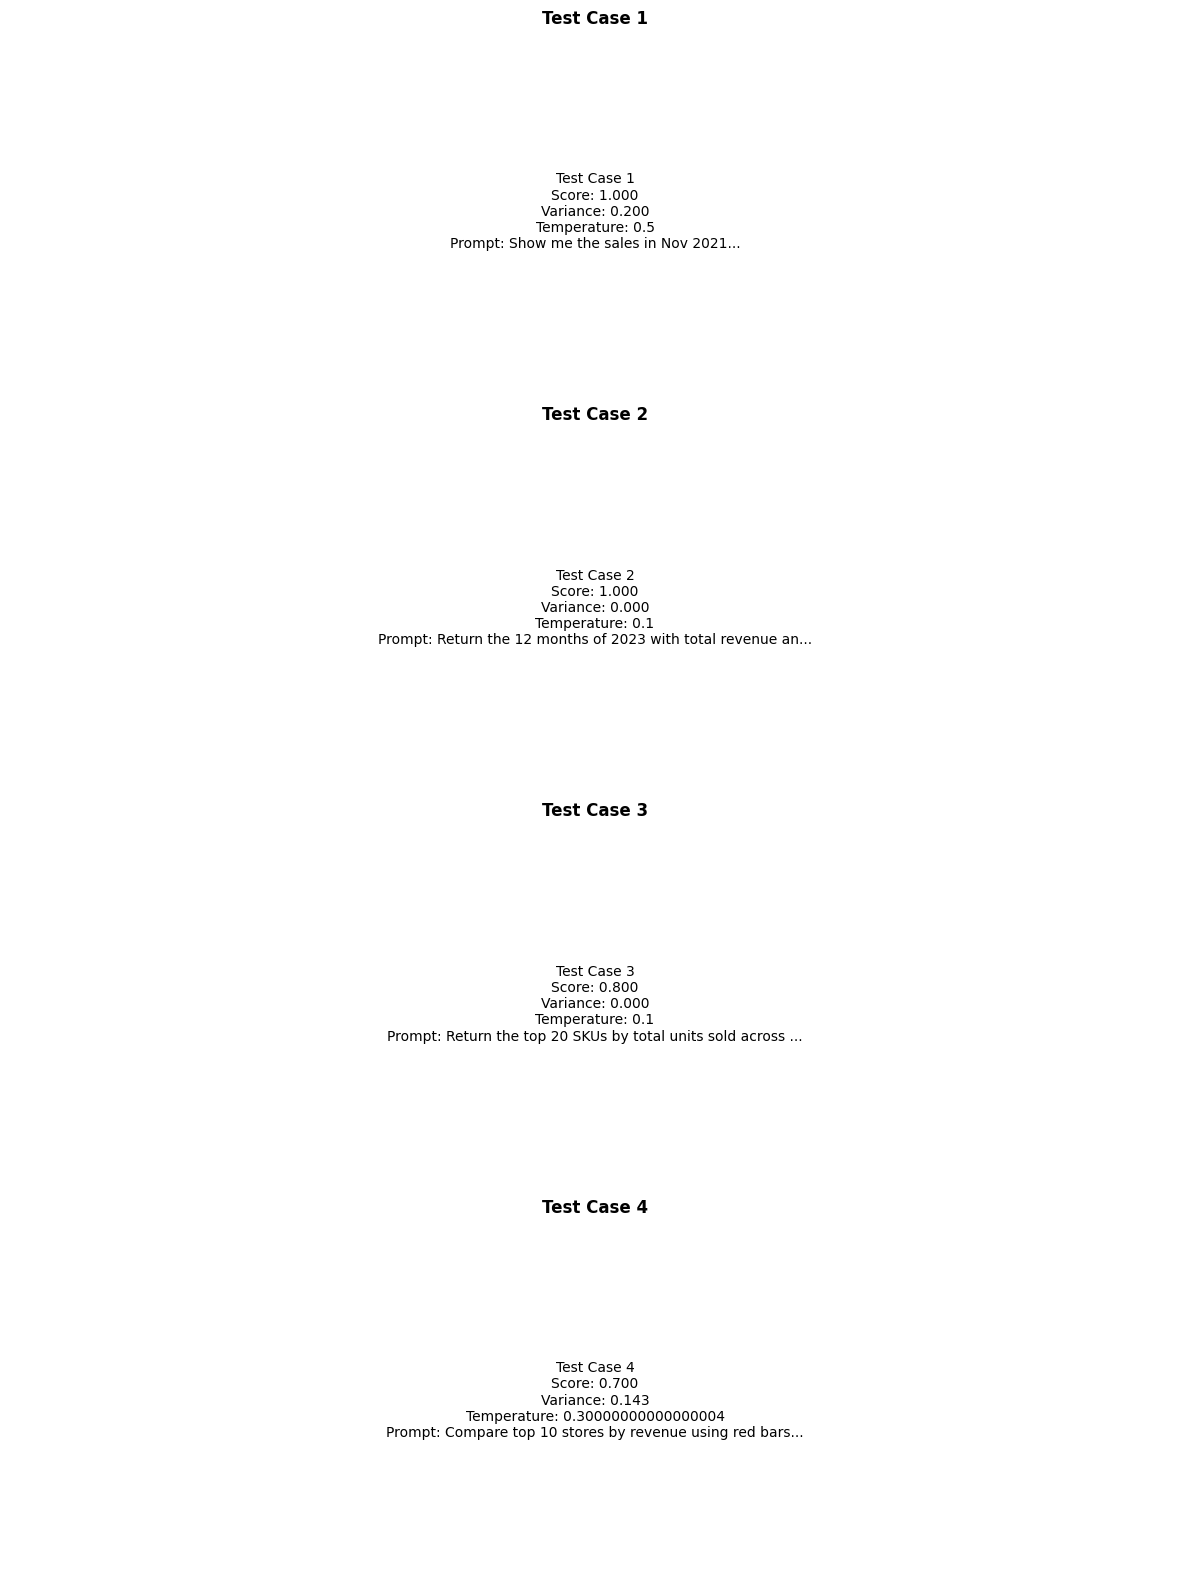


📊 To see actual generated charts, you'll need to execute them individually
The generated chart configs and codes are saved in the results DataFrame


In [16]:
# Optional: Display all generated visualizations for visual inspection
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(results), 1, figsize=(12, 4*len(results)))
if len(results) == 1:
    axes = [axes]

for idx, result_entry in enumerate(results):
    # Find the corresponding full result from the results list
    # Note: You may need to save the full results in the previous cell if you want to display them here
    ax = axes[idx]
    ax.text(0.5, 0.5, 
            f"Test Case {idx+1}\n"
            f"Score: {result_entry['vis_score']:.3f}\n"
            f"Variance: {result_entry['score_variance']:.3f}\n"
            f"Temperature: {result_entry['best_temperature']}\n"
            f"Prompt: {result_entry['prompt'][:50]}...",
            ha='center', va='center', fontsize=10, wrap=True)
    ax.axis('off')
    ax.set_title(f"Test Case {idx+1}", fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 To see actual generated charts, you'll need to execute them individually")
print("The generated chart configs and codes are saved in the results DataFrame")